#  AirSense-XAI
## Explainable Machine Learning for Urban Air Quality Prediction

### Project Objective

Air pollution is an important environmental problem that can have serious effects on human health and urban living conditions. This project develops machine learning models to predict PM2.5 concentration using air-quality and meteorological variables.

The project also applies Explainable Artificial Intelligence (XAI), particularly SHAP (SHapley Additive exPlanations), to understand which environmental factors contribute most to the model's predictions.

The project follows an end-to-end machine learning workflow:

Dataset → Data Cleaning → Exploratory Data Analysis → Feature Engineering → Machine Learning → Model Evaluation → Explainable AI → Research Findings

#  Research Questions

This project investigates the following research questions:

1. Which machine learning model provides the most accurate PM2.5 predictions?

2. Which environmental variables have the greatest influence on PM2.5 predictions?

3. How do meteorological variables such as temperature, pressure, humidity and wind speed relate to PM2.5?

4. Does incorporating temporal information improve prediction performance?

5. Can SHAP provide meaningful explanations for individual PM2.5 predictions?

# Dataset Description

This project uses the Beijing Multi-Site Air Quality Dataset from the UCI Machine Learning Repository.

The dataset contains hourly air-quality and meteorological observations collected from multiple monitoring stations in Beijing.

Important variables include:

- PM2.5
- PM10
- SO2
- NO2
- CO
- O3
- Temperature
- Atmospheric pressure
- Dew point
- Rain
- Wind direction
- Wind speed
- Date and time information

### Target Variable

The target variable for this project is:

**PM2.5**

PM2.5 represents fine particulate matter with an aerodynamic diameter of 2.5 micrometers or smaller.

In [ ]:
# Install required packages
!pip install -q shap xgboost

# Import Libraries

Python libraries are used for data manipulation, statistical analysis,
visualization, machine learning, model evaluation and Explainable AI.

The main libraries used in this project include Pandas and NumPy for
data processing, Matplotlib and Seaborn for visualization, Scikit-learn
for machine learning, XGBoost for gradient boosting, and SHAP for
Explainable AI.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# XGBoost
from xgboost import XGBRegressor

# Explainable AI
import shap

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:
from google.colab import files
uploaded = files.upload()

Saving beijing+multi+site+air+quality+data.zip to beijing+multi+site+air+quality+data.zip


# Dataset Extraction

The downloaded dataset is provided as a compressed ZIP archive.
The archive contains air-quality observations collected from multiple
monitoring stations in Beijing.

The PRSA2017 archive is extracted to access the individual monitoring
station datasets.

The separate data.csv file present in the outer directory is not used
because it does not contain the air-quality variables required for this
study.

In [ ]:
import zipfile
import os

# Path of the PRSA2017 ZIP file
inner_zip = "beijing_air_quality/PRSA2017_Data_20130301-20170228.zip"

# Extract the PRSA2017 dataset
with zipfile.ZipFile(inner_zip, "r") as zip_ref:
    zip_ref.extractall("beijing_air_quality/PRSA2017")

print("PRSA2017 air-quality dataset extracted successfully!")

PRSA2017 air-quality dataset extracted successfully!


# Monitoring Station Identification

The PRSA2017 dataset contains observations from multiple air-quality
monitoring stations.

The available station files are listed to identify the datasets
available for analysis.

In [ ]:
for root, dirs, files in os.walk("beijing_air_quality/PRSA2017"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

beijing_air_quality/PRSA2017/PRSA_Data_20130301-20170228/PRSA_Data_Shunyi_20130301-20170228.csv
beijing_air_quality/PRSA2017/PRSA_Data_20130301-20170228/PRSA_Data_Tiantan_20130301-20170228.csv
beijing_air_quality/PRSA2017/PRSA_Data_20130301-20170228/PRSA_Data_Gucheng_20130301-20170228.csv
beijing_air_quality/PRSA2017/PRSA_Data_20130301-20170228/PRSA_Data_Nongzhanguan_20130301-20170228.csv
beijing_air_quality/PRSA2017/PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv
beijing_air_quality/PRSA2017/PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv
beijing_air_quality/PRSA2017/PRSA_Data_20130301-20170228/PRSA_Data_Wanliu_20130301-20170228.csv
beijing_air_quality/PRSA2017/PRSA_Data_20130301-20170228/PRSA_Data_Huairou_20130301-20170228.csv
beijing_air_quality/PRSA2017/PRSA_Data_20130301-20170228/PRSA_Data_Guanyuan_20130301-20170228.csv
beijing_air_quality/PRSA2017/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv
beijing_air_qualit

# Monitoring Station Selection

The Aotizhongxin monitoring station is selected for the initial
development of the AirSense-XAI framework.

The station provides hourly observations of air pollutants and
meteorological variables over an extended period.

The analysis initially focuses on one monitoring station to develop
and evaluate the complete machine learning pipeline before extending
the approach to multiple stations.

In [ ]:
import pandas as pd

station_file = (
    "beijing_air_quality/PRSA2017/"
    "PRSA_Data_20130301-20170228/"
    "PRSA_Data_Aotizhongxin_20130301-20170228.csv"
)

df = pd.read_csv(station_file)

print("Aotizhongxin dataset loaded successfully!")
print("Dataset shape:", df.shape)

Aotizhongxin dataset loaded successfully!
Dataset shape: (35064, 18)


In [ ]:
print("Column names:")
print(df.columns.tolist())

Column names:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']


In [ ]:
display(df.head())

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


# Initial Dataset Inspection

The structure of the dataset is examined before performing detailed
data cleaning and exploratory analysis.

The inspection includes the number of observations, number of
variables, column names and the first few observations.

In [ ]:
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst five observations:")
display(df.head())

Number of rows and columns:
(35064, 18)

Column names:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

First five observations:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


# Dataset Information

The data types and non-null counts of the variables are examined to
understand the structure and completeness of the dataset.

This step helps identify variables that may require conversion or
additional preprocessing.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


# Statistical Summary

Descriptive statistics are calculated for the numerical variables.

The summary provides information about the mean, standard deviation,
minimum, maximum and quartile values of the observations.

In [ ]:
display(df.describe())

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


# Missing Value Analysis

Air-quality monitoring systems can produce missing observations due
to sensor malfunction, maintenance or interruptions in data collection.

Missing values are therefore identified and quantified before
performing machine learning.

In [ ]:
missing_values = df.isnull().sum()

print("Missing values by feature:")
print(missing_values)

Missing values by feature:
No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64


In [ ]:
missing_percentage = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print("\nMissing percentage by feature:")
print(missing_percentage)


Missing percentage by feature:
CO         5.065024
O3         4.902464
NO2        2.917522
SO2        2.666553
PM2.5      2.638033
PM10       2.047684
wd         0.231006
RAIN       0.057039
DEWP       0.057039
PRES       0.057039
TEMP       0.057039
WSPM       0.039927
year       0.000000
No         0.000000
day        0.000000
month      0.000000
hour       0.000000
station    0.000000
dtype: float64


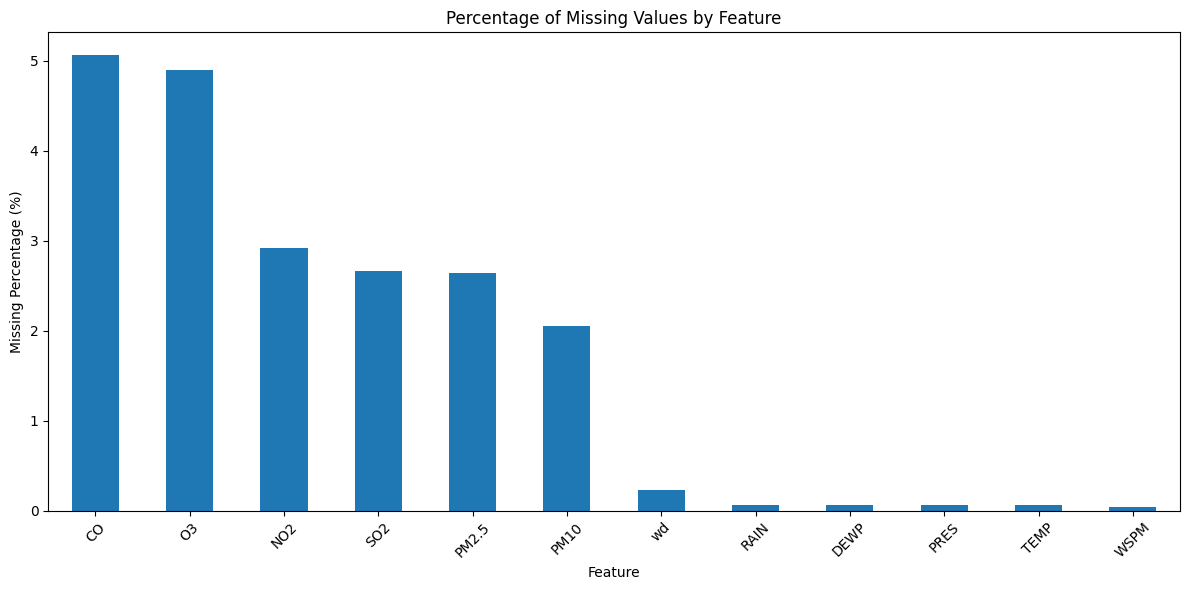

In [ ]:
missing_to_plot = missing_percentage[
    missing_percentage > 0
]

if missing_to_plot.empty:
    print("No missing values were found in the dataset.")
else:
    plt.figure(figsize=(12, 6))

    missing_to_plot.plot(kind="bar")

    plt.title("Percentage of Missing Values by Feature")
    plt.xlabel("Feature")
    plt.ylabel("Missing Percentage (%)")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Duplicate Analysis

Duplicate observations may introduce bias into machine learning
models.

The dataset is therefore checked for duplicate rows before proceeding
with further analysis.

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


# Date-Time Processing

The dataset stores year, month, day and hour as separate variables.

These variables are combined into a single datetime variable to
facilitate temporal analysis and feature engineering.

The observations are then sorted chronologically.

In [ ]:
df["datetime"] = pd.to_datetime(
    df[["year", "month", "day", "hour"]]
)

df = df.sort_values("datetime").reset_index(drop=True)

print("Start date:", df["datetime"].min())
print("End date:", df["datetime"].max())

Start date: 2013-03-01 00:00:00
End date: 2017-02-28 23:00:00


In [ ]:
display(
    df[
        ["datetime", "year", "month", "day", "hour", "PM2.5"]
    ].head()
)

,datetime,year,month,day,hour,PM2.5
0,2013-03-01 00:00:00,2013,3,1,0,4.0
1,2013-03-01 01:00:00,2013,3,1,1,8.0
2,2013-03-01 02:00:00,2013,3,1,2,7.0
3,2013-03-01 03:00:00,2013,3,1,3,6.0
4,2013-03-01 04:00:00,2013,3,1,4,3.0


# Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the
distribution, temporal behaviour and relationships between PM2.5
concentration and other environmental variables.

The analysis includes PM2.5 distribution, temporal trends, hourly
patterns, seasonal patterns and feature correlations.

# PM2.5 Distribution

The distribution of PM2.5 concentration is visualized to understand
its range, central tendency, variability and potential skewness.

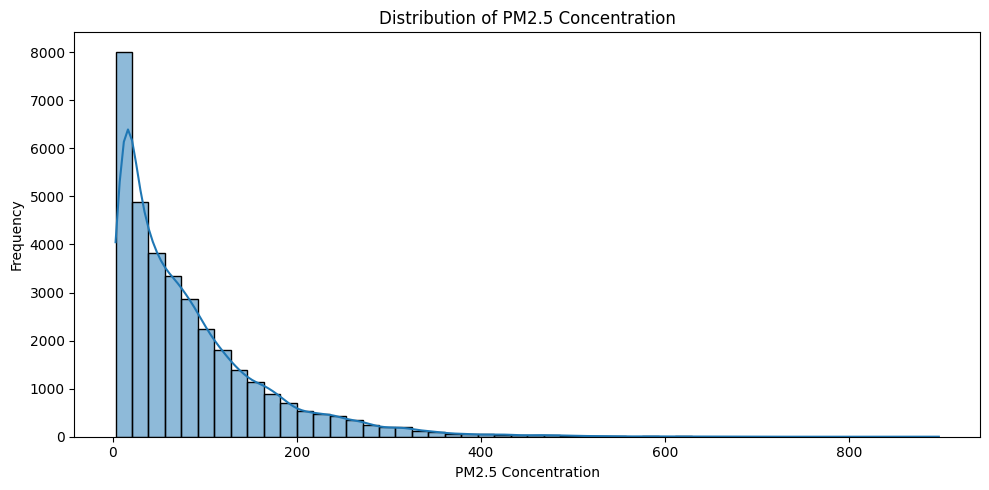

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["PM2.5"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of PM2.5 Concentration")
plt.xlabel("PM2.5 Concentration")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# PM2.5 Concentration Over Time

The PM2.5 concentration is plotted against time to identify long-term
variations and periods of increased or decreased air pollution.

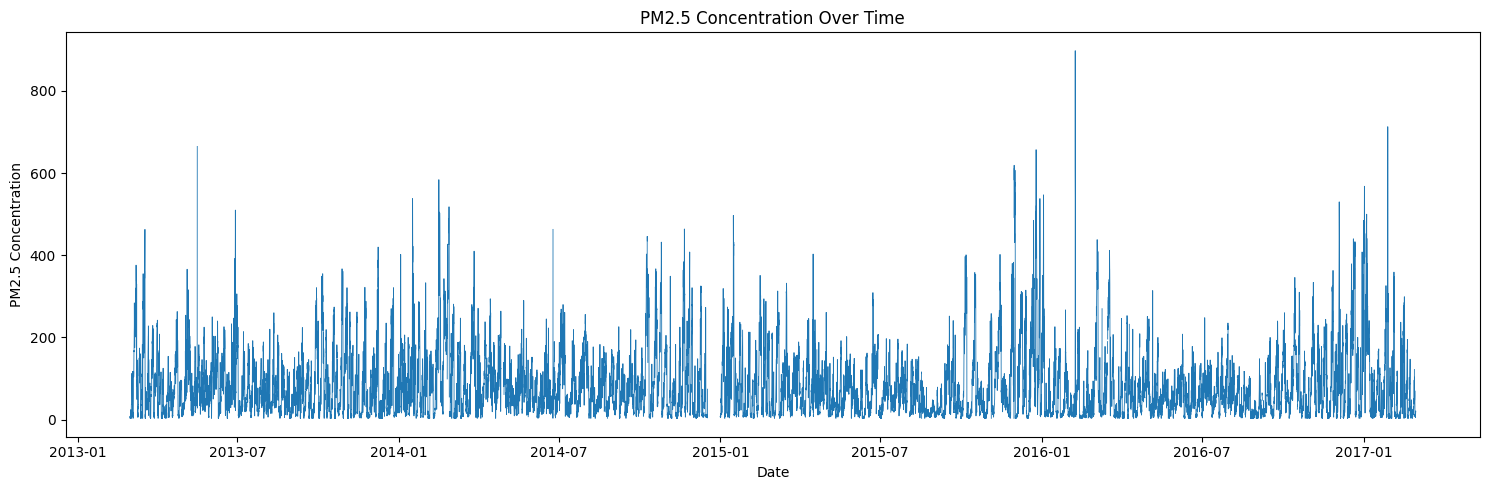

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["datetime"],
    df["PM2.5"],
    linewidth=0.6
)

plt.title("PM2.5 Concentration Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5 Concentration")

plt.tight_layout()
plt.show()

# Monthly PM2.5 Analysis

Monthly average PM2.5 concentrations are calculated to investigate
whether air pollution levels vary across different months of the year.

In [ ]:
monthly_pm25 = (
    df.groupby("month")["PM2.5"]
      .mean()
)

print(monthly_pm25)

month
1      92.817045
2      85.840645
3      99.999384
4      76.177490
5      67.340081
6      71.820177
7      75.256909
8      55.639271
9      64.456092
10     96.385923
11     98.539698
12    111.315184
Name: PM2.5, dtype: float64


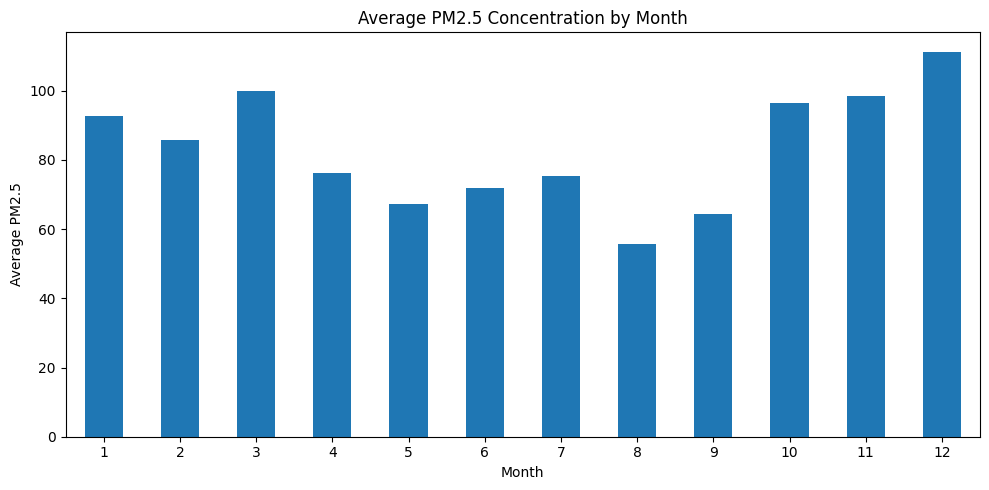

In [ ]:
plt.figure(figsize=(10, 5))

monthly_pm25.plot(
    kind="bar"
)

plt.title("Average PM2.5 Concentration by Month")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Hourly PM2.5 Analysis

Average PM2.5 concentration is calculated for each hour of the day.

This analysis helps identify recurring daily pollution patterns and
potential differences between daytime and nighttime conditions.

In [ ]:
hourly_pm25 = (
    df.groupby("hour")["PM2.5"]
      .mean()
)

print(hourly_pm25)

hour
0     92.301399
1     92.069279
2     91.687124
3     88.736613
4     85.336134
5     81.729091
6     79.775681
7     77.551927
8     77.742297
9     78.531646
10    79.213380
11    79.662162
12    79.015592
13    77.997883
14    77.126412
15    76.464159
16    75.887997
17    76.362482
18    78.225829
19    82.372082
20    86.276961
21    89.250384
22    90.869839
23    91.870490
Name: PM2.5, dtype: float64


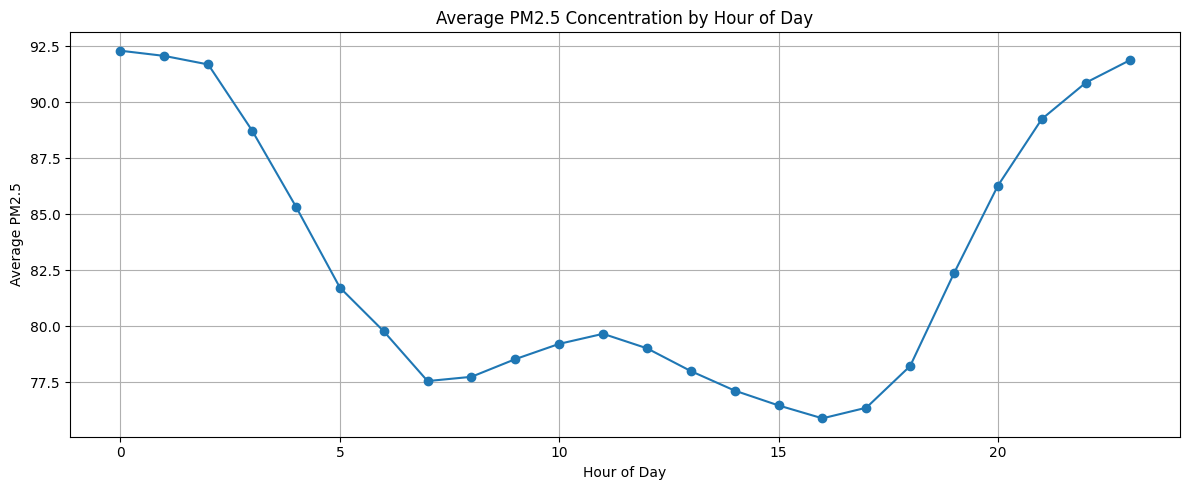

In [ ]:
plt.figure(figsize=(12, 5))

hourly_pm25.plot(
    marker="o"
)

plt.title("Average PM2.5 Concentration by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5")

plt.grid(True)

plt.tight_layout()
plt.show()

# Seasonal PM2.5 Analysis

Seasonal variation is examined because atmospheric and meteorological
conditions can change throughout the year.

The observations are grouped into Winter, Spring, Summer and Autumn,
and their average PM2.5 concentrations are compared.

In [ ]:
def assign_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"


df["season"] = df["month"].apply(assign_season)

seasonal_pm25 = (
    df.groupby("season")["PM2.5"]
      .mean()
      .reindex([
          "Winter",
          "Spring",
          "Summer",
          "Autumn"
      ])
)

print(seasonal_pm25)

season
Winter    96.419900
Spring    81.230224
Summer    67.551824
Autumn    86.589328
Name: PM2.5, dtype: float64


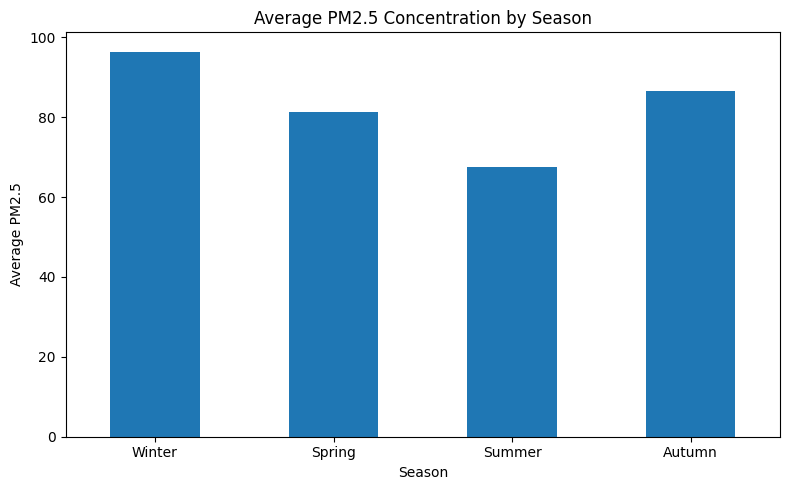

In [ ]:
plt.figure(figsize=(8, 5))

seasonal_pm25.plot(
    kind="bar"
)

plt.title("Average PM2.5 Concentration by Season")
plt.xlabel("Season")
plt.ylabel("Average PM2.5")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Correlation Analysis

Correlation analysis is performed to investigate relationships between
PM2.5 and other air-quality and meteorological variables.

This provides an initial understanding of potentially important
predictors before machine learning.

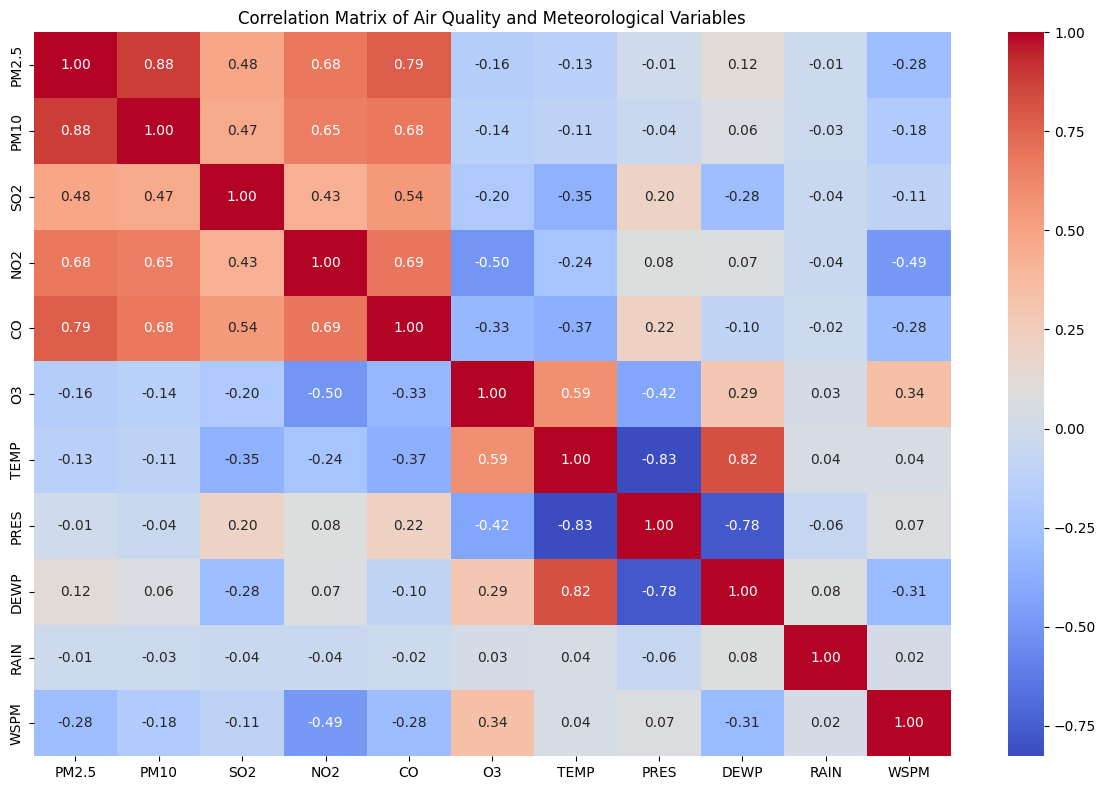

In [ ]:
numeric_features = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM"
]

correlation = df[
    numeric_features
].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Air Quality and Meteorological Variables")

plt.tight_layout()
plt.show()

# Feature Engineering

Feature engineering is performed to provide the machine learning
models with additional temporal information.

The datetime variable is used to derive hour, month, day of week and
year features.

These variables allow the models to capture recurring temporal
patterns in PM2.5 concentration.

In [ ]:
df["hour"] = df["datetime"].dt.hour
df["month"] = df["datetime"].dt.month
df["day_of_week"] = df["datetime"].dt.dayofweek
df["year"] = df["datetime"].dt.year

display(
    df[
        [
            "datetime",
            "hour",
            "month",
            "day_of_week",
            "year",
            "PM2.5"
        ]
    ].head()
)

,datetime,hour,month,day_of_week,year,PM2.5
0,2013-03-01 00:00:00,0,3,4,2013,4.0
1,2013-03-01 01:00:00,1,3,4,2013,8.0
2,2013-03-01 02:00:00,2,3,4,2013,7.0
3,2013-03-01 03:00:00,3,3,4,2013,6.0
4,2013-03-01 04:00:00,4,3,4,2013,3.0


# Machine Learning Dataset Preparation

PM2.5 concentration is selected as the target variable.

Air-quality and meteorological variables are used as predictor
features.

Temporal features are also included to help the models capture
time-dependent patterns.

Rows containing missing values in the selected modelling variables
are removed before model training.

In [ ]:
features = [
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM",
    "hour",
    "month",
    "day_of_week",
    "year"
]

target = "PM2.5"

model_df = df[
    features + [target]
].copy()

model_df = model_df.dropna()

print("Final modelling dataset shape:", model_df.shape)

Final modelling dataset shape: (31876, 15)


# Time-Based Train-Test Split

Since air-quality observations are time-dependent, a chronological
train-test split is used instead of randomly shuffling the data.

The first 80% of observations are used for training and the remaining
20% are used for testing.

This approach helps reduce temporal data leakage by ensuring that
future observations are not used to train the model.

In [ ]:
split_index = int(
    len(model_df) * 0.80
)

train = model_df.iloc[:split_index]
test = model_df.iloc[split_index:]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25500
Testing samples: 6376


# Baseline Model — Linear Regression

Linear Regression is used as a baseline machine learning model.

It provides a simple reference point against which more complex
nonlinear models can be evaluated.

In [ ]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(
    y_test,
    pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        pred_lr
    )
)

r2_lr = r2_score(
    y_test,
    pred_lr
)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
MAE : 17.442762811090816
RMSE: 25.264373023241156
R²  : 0.9134470606581859


# Decision Tree Regression

A Decision Tree Regressor is evaluated to capture nonlinear
relationships between environmental variables and PM2.5 concentration.

In [ ]:
dt = DecisionTreeRegressor(
    max_depth=15,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(
    y_test,
    pred_dt
)

rmse_dt = np.sqrt(
    mean_squared_error(
        y_test,
        pred_dt
    )
)

r2_dt = r2_score(
    y_test,
    pred_dt
)

print("Decision Tree")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree
MAE : 16.0085396649997
RMSE: 28.6579304493123
R²  : 0.8886335387532456


# Random Forest Regression

Random Forest is an ensemble learning algorithm that combines
multiple decision trees.

It is evaluated because ensemble methods can capture nonlinear
relationships and interactions between environmental variables.

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(
    y_test,
    pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    pred_rf
)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
MAE : 13.38530889272271
RMSE: 21.828432951598963
R²  : 0.9353884902096475


# XGBoost Regression

XGBoost is evaluated as an advanced gradient-boosting model.

Its ability to learn nonlinear relationships and feature interactions
makes it suitable for predicting PM2.5 concentration from complex
environmental data.

In [ ]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(
    y_test,
    pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        pred_xgb
    )
)

r2_xgb = r2_score(
    y_test,
    pred_xgb
)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost
MAE : 12.936695489569695
RMSE: 21.33111296466975
R²  : 0.9382990568780336


# Model Evaluation and Comparison

Four machine learning models were evaluated for PM2.5 prediction:
Linear Regression, Decision Tree, Random Forest and XGBoost.

The models are compared using Mean Absolute Error (MAE), Root Mean
Squared Error (RMSE) and R².

MAE and RMSE measure prediction error, where lower values indicate
better performance.

R² measures the proportion of variance in PM2.5 concentration explained
by the model, where a higher value indicates better performance.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_xgb
    ],
    "R2": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_xgb
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,17.442763,25.264373,0.913447
1,Decision Tree,16.008540,28.657930,0.888634
2,Random Forest,13.385309,21.828433,0.935388
3,XGBoost,12.936695,21.331113,0.938299


In [ ]:
print(results.to_string(index=False))

            Model       MAE      RMSE       R2
Linear Regression 17.442763 25.264373 0.913447
    Decision Tree 16.008540 28.657930 0.888634
    Random Forest 13.385309 21.828433 0.935388
          XGBoost 12.936695 21.331113 0.938299


# Best Model Identification

The best-performing model is identified based on the evaluation
metrics.

The model with the lowest RMSE and MAE and highest R² is considered
the strongest predictive model among the evaluated models.

In [ ]:
best_rmse_model = results.loc[
    results["RMSE"].idxmin(),
    "Model"
]

best_mae_model = results.loc[
    results["MAE"].idxmin(),
    "Model"
]

best_r2_model = results.loc[
    results["R2"].idxmax(),
    "Model"
]

print("Best model based on RMSE:", best_rmse_model)
print("Best model based on MAE :", best_mae_model)
print("Best model based on R²   :", best_r2_model)

# RMSE Comparison

The RMSE values of the four models are visualized to compare their
prediction errors.

A lower RMSE indicates that the model produces smaller prediction
errors, particularly for larger deviations.

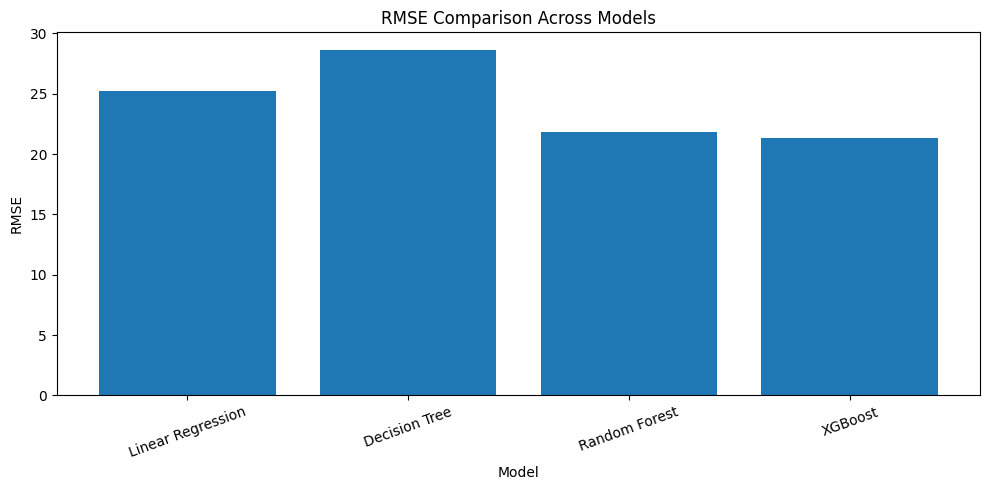

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("RMSE Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# R² Comparison

The R² scores of the evaluated models are visualized.

A higher R² indicates that the model explains a larger proportion of
the variation in PM2.5 concentration.

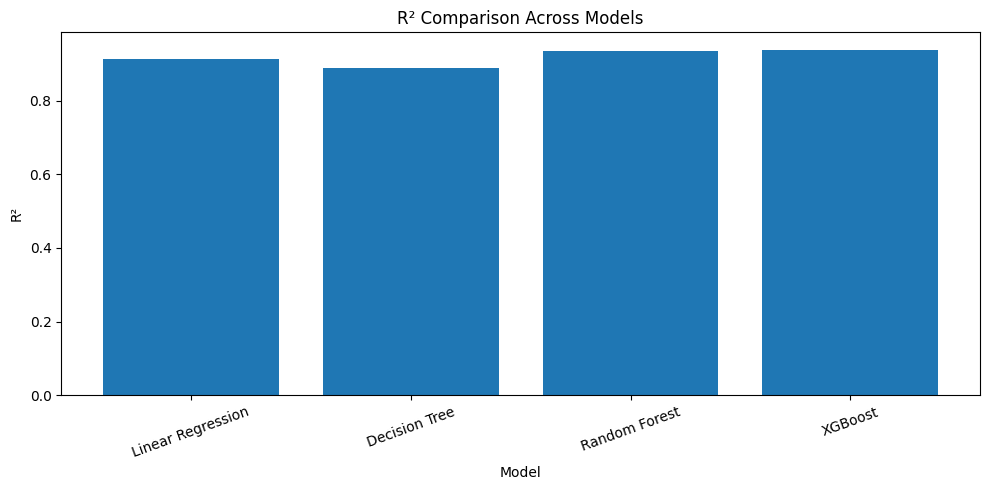

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["R2"]
)

plt.title("R² Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("R²")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# Actual vs Predicted PM2.5

The actual and predicted PM2.5 concentrations generated by the XGBoost
model are compared over the test period.

This visualization provides a qualitative assessment of how closely
the model follows the observed PM2.5 variations.

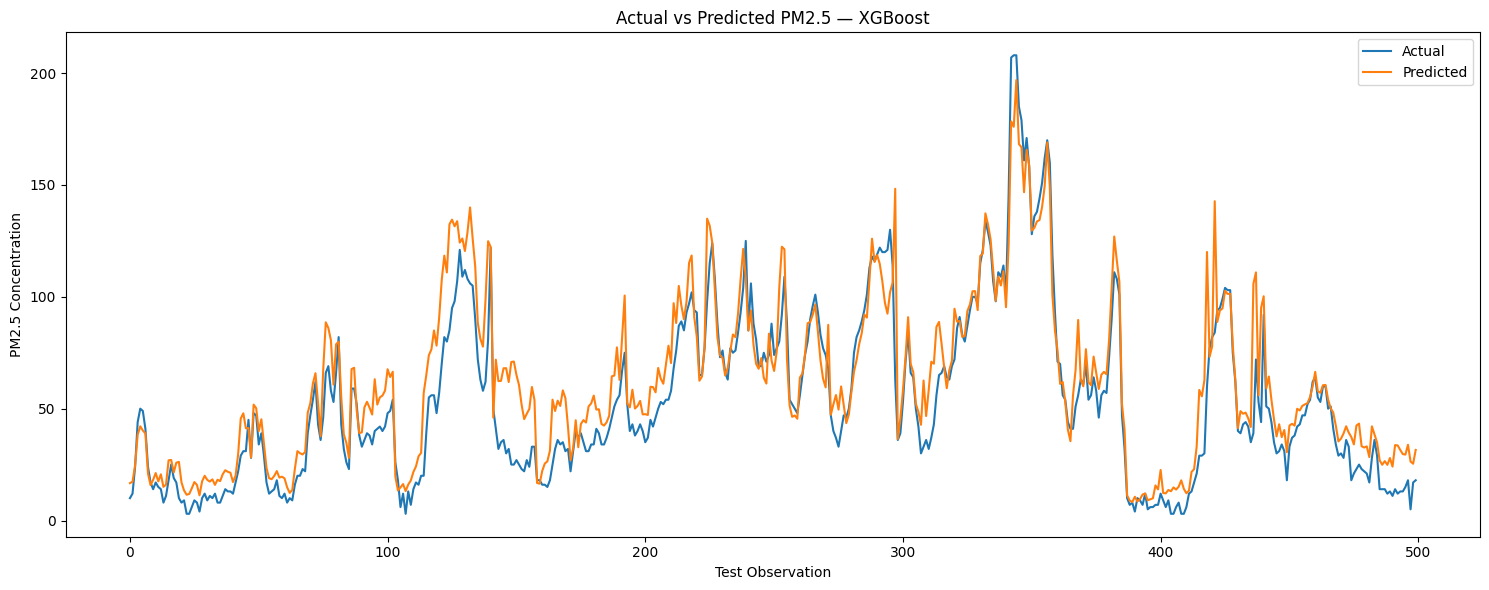

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.values[:500],
    label="Actual"
)

plt.plot(
    pred_xgb[:500],
    label="Predicted"
)

plt.title("Actual vs Predicted PM2.5 — XGBoost")
plt.xlabel("Test Observation")
plt.ylabel("PM2.5 Concentration")

plt.legend()

plt.tight_layout()
plt.show()

# Actual vs Predicted Scatter Analysis

A scatter plot is used to compare actual PM2.5 concentrations with
XGBoost predictions.

Points closer to the diagonal reference line indicate predictions
that are closer to the observed values.

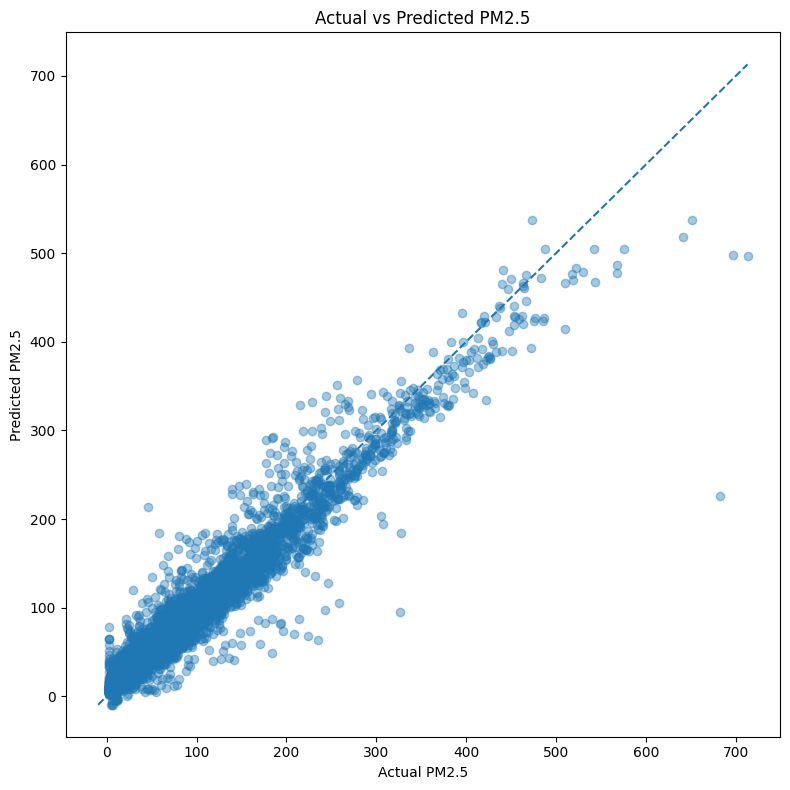

In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    pred_xgb,
    alpha=0.4
)

min_value = min(
    y_test.min(),
    pred_xgb.min()
)

max_value = max(
    y_test.max(),
    pred_xgb.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted PM2.5")
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")

plt.tight_layout()
plt.show()

# Explainable Artificial Intelligence using SHAP

Machine learning models can achieve high predictive performance while
remaining difficult to interpret.

To address this limitation, Explainable Artificial Intelligence (XAI)
is incorporated into AirSense-XAI.

SHAP (SHapley Additive exPlanations) is used to quantify the contribution
of individual features to the model's predictions.

The analysis provides both global and local explanations of the
XGBoost model.


In [ ]:
explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")
print("SHAP shape:", shap_values.shape)

SHAP values calculated successfully!
SHAP shape: (6376, 14)


# Global Feature Impact

The SHAP summary plot provides a global explanation of the XGBoost
model.

Features are ranked according to their overall contribution to model
predictions.

The position and colour of the points provide information about both
the magnitude and direction of feature effects.

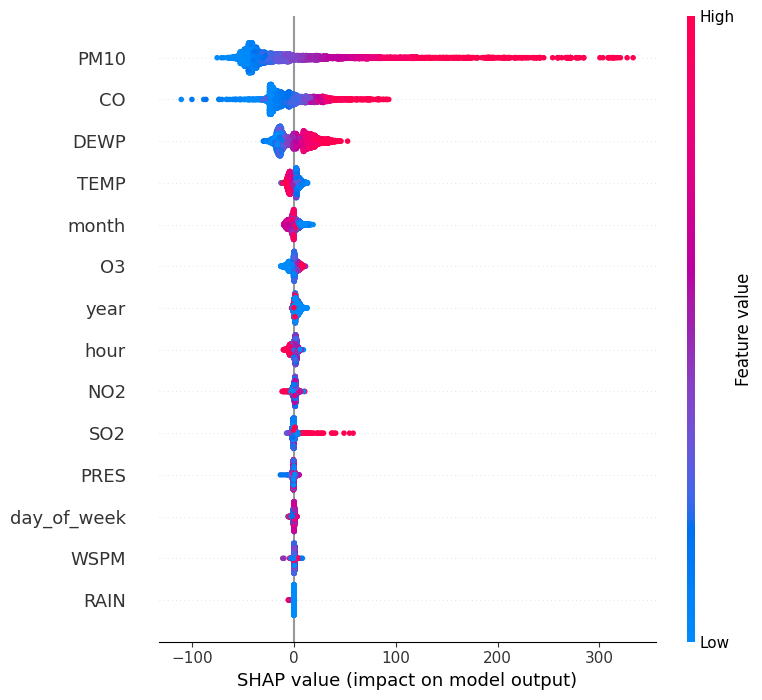

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

# SHAP Feature Importance

A bar-based SHAP summary is used to rank the features according to
their mean absolute SHAP values.

Higher mean absolute SHAP values indicate greater overall influence
on the model's predictions.

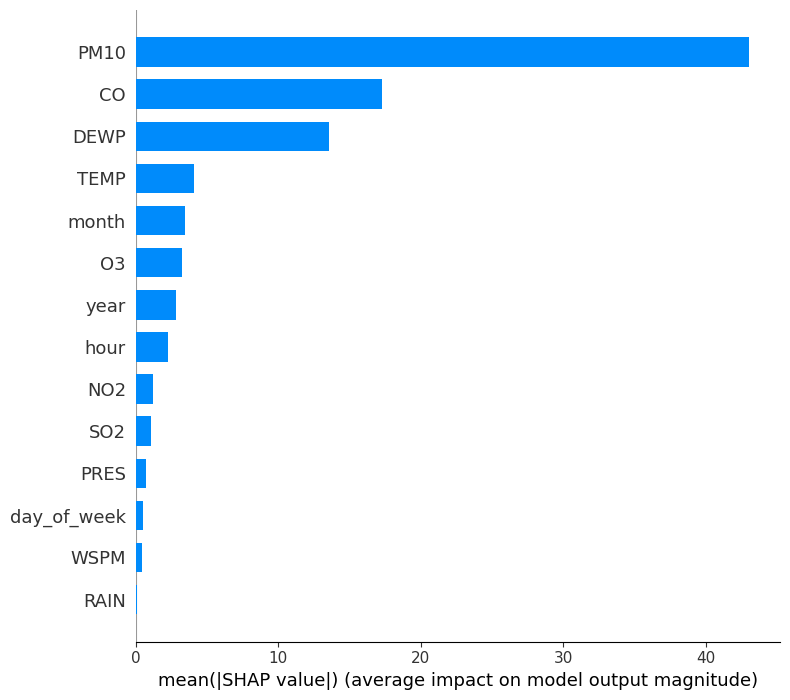

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [ ]:
print(results.to_string(index=False))

            Model       MAE      RMSE       R2
Linear Regression 17.442763 25.264373 0.913447
    Decision Tree 16.008540 28.657930 0.888634
    Random Forest 13.385309 21.828433 0.935388
          XGBoost 12.936695 21.331113 0.938299


In [6]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        17.442763,
        16.008540,
        13.385309,
        12.936695
    ],
    "RMSE": [
        25.264373,
        28.657930,
        21.828433,
        21.331113
    ],
    "R2": [
        0.913447,
        0.888634,
        0.935388,
        0.938299
    ]
})

print("Model comparison results:")
display(results)

results.to_csv("model_results.csv", index=False)

print("\n model_results.csv saved successfully!")

Model comparison results:


,Model,MAE,RMSE,R2
0,Linear Regression,17.442763,25.264373,0.913447
1,Decision Tree,16.008540,28.657930,0.888634
2,Random Forest,13.385309,21.828433,0.935388
3,XGBoost,12.936695,21.331113,0.938299



 model_results.csv saved successfully!


In [7]:
results.to_csv("model_results.csv", index=False)

print("Model results saved successfully!")

Model results saved successfully!


In [8]:
from google.colab import files

files.download("model_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Model Comparison Findings

The experimental results demonstrate that XGBoost achieved the strongest
overall performance among the four evaluated models.

XGBoost obtained the lowest MAE of 12.94 and the lowest RMSE of 21.33,
while achieving the highest R² score of 0.9383.

Random Forest also demonstrated strong predictive performance with an
R² of 0.9354 and an RMSE of 21.83.

Linear Regression achieved an R² of 0.9134, indicating that a substantial
portion of the variation in PM2.5 can be explained using the selected
features, although its prediction error was higher than the ensemble
models.

Decision Tree produced an R² of 0.8886 and the highest RMSE of 28.66,
indicating comparatively weaker generalization performance.

Based on the evaluation metrics, XGBoost was selected as the primary
model for the Explainable AI analysis.

# Explainable AI using SHAP

Although XGBoost provides strong predictive performance, its internal
decision-making process is not directly interpretable.

SHAP (SHapley Additive exPlanations) is therefore used to explain the
contribution of individual features to the model predictions.

The SHAP analysis helps identify which environmental and temporal
variables have the greatest influence on PM2.5 predictions.

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")
print("SHAP values shape:", shap_values.shape)

SHAP values calculated successfully!
SHAP values shape: (6376, 14)


# Global SHAP Feature Analysis

The SHAP summary plot provides a global interpretation of the XGBoost
model.

Features are ranked according to their overall contribution to model
predictions.

The colour of each point represents the feature value, while the
horizontal position represents the impact of the feature on the model
output.

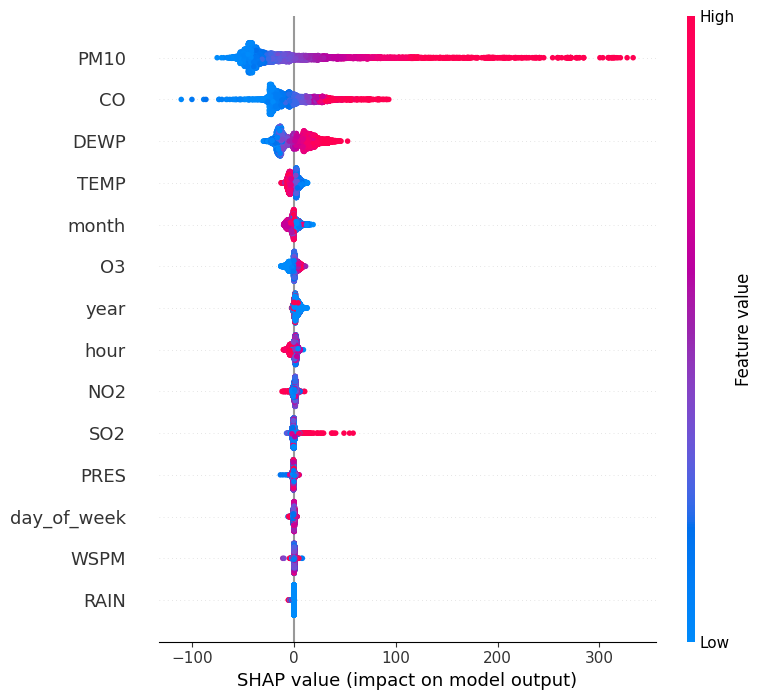

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

# SHAP Feature Importance Ranking

Mean absolute SHAP values are used to rank the features according to
their overall importance.

A higher mean absolute SHAP value indicates that the corresponding
feature has a greater overall influence on the XGBoost predictions.

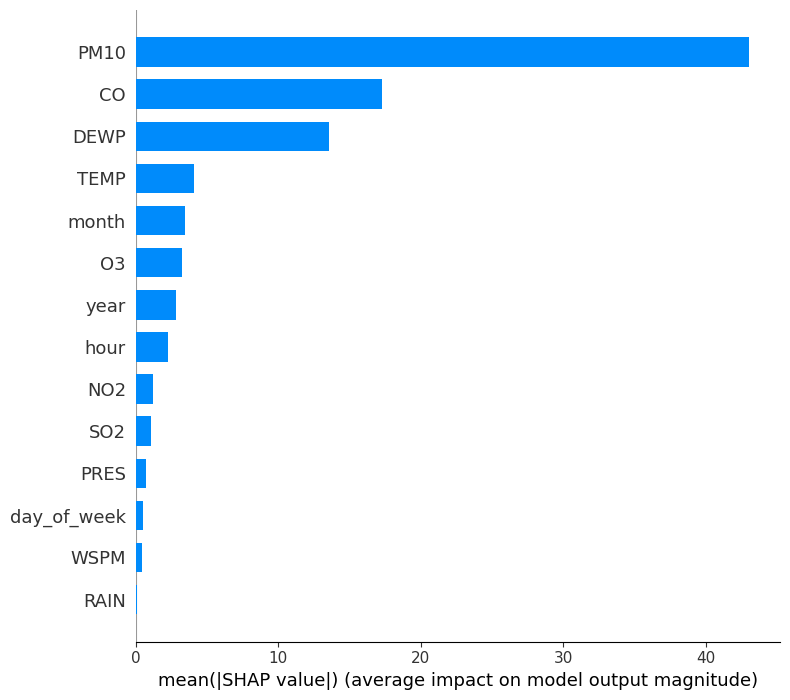

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

# SHAP Analysis Findings

The SHAP analysis provides an interpretable view of the XGBoost model's
decision-making process.

PM10 was identified as the most influential feature by a substantial
margin, followed by CO and DEWP. This indicates that particulate and
pollutant-related measurements play an important role in the model's
PM2.5 predictions.

The SHAP beeswarm plot shows that higher PM10 values generally produce
positive SHAP values, increasing the predicted PM2.5 concentration.
Lower PM10 values generally have the opposite effect.

CO was the second most influential feature. Higher CO observations
generally contributed positively to the predicted PM2.5 values.

DEWP was the third most influential feature and also demonstrated a
noticeable contribution to the model output.

Temperature showed a comparatively smaller contribution. In the SHAP
distribution, higher temperature observations were generally associated
with negative SHAP values, while lower temperature observations were
more frequently associated with positive contributions.

The temporal variables, including month, year, hour and day of week,
had comparatively smaller mean absolute SHAP values.

Overall, the SHAP analysis demonstrates that the XGBoost model is
primarily influenced by measured environmental and pollutant variables,
with PM10 being the dominant predictor.

# Numerical SHAP Feature Ranking

Mean absolute SHAP values are calculated for each feature and sorted
in descending order.

This ranking provides a quantitative measure of the overall influence
of each feature on the XGBoost predictions.

In [ ]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

display(shap_importance)

,Feature,Mean_Absolute_SHAP
0,PM10,43.055649
1,CO,17.301447
2,DEWP,13.546266
3,TEMP,4.088726
4,month,3.434446
5,O3,3.238675
6,year,2.815659
7,hour,2.239287
8,NO2,1.245212
9,SO2,1.091072


In [ ]:
print("Top 5 most influential features:")
display(shap_importance.head(5))

Top 5 most influential features:


,Feature,Mean_Absolute_SHAP
0,PM10,43.055649
1,CO,17.301447
2,DEWP,13.546266
3,TEMP,4.088726
4,month,3.434446


# SHAP Dependence Analysis — PM10

PM10 was identified as the most influential feature in the global SHAP
analysis.

A SHAP dependence plot is therefore used to examine the relationship
between PM10 values and their contribution to the XGBoost prediction.

This analysis helps determine whether increasing PM10 generally pushes
the prediction upward or downward.

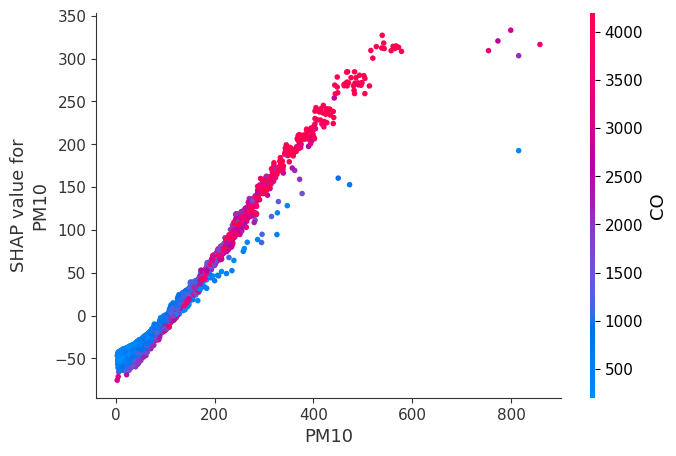

In [ ]:
shap.dependence_plot(
    "PM10",
    shap_values,
    X_test
)

# SHAP Dependence Analysis — CO

CO was identified as the second most influential feature.

A SHAP dependence plot is used to examine how changes in CO values
affect the model's PM2.5 predictions.

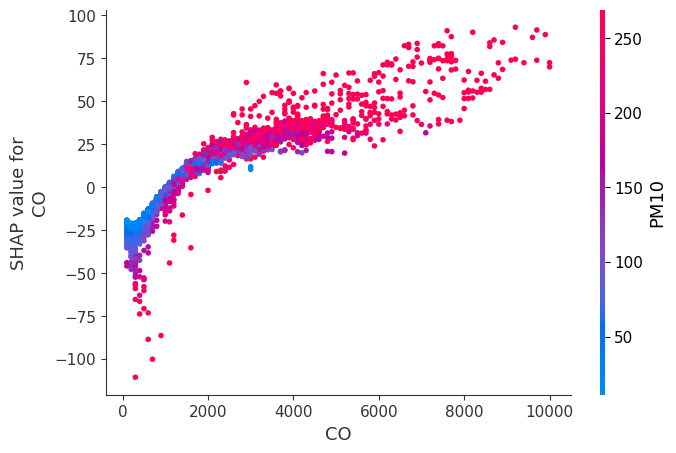

In [ ]:
shap.dependence_plot(
    "CO",
    shap_values,
    X_test
)

# SHAP Dependence Analysis — DEWP

DEWP was identified as the third most influential feature.

The dependence plot is used to investigate how dew-point values
contribute to individual PM2.5 predictions.

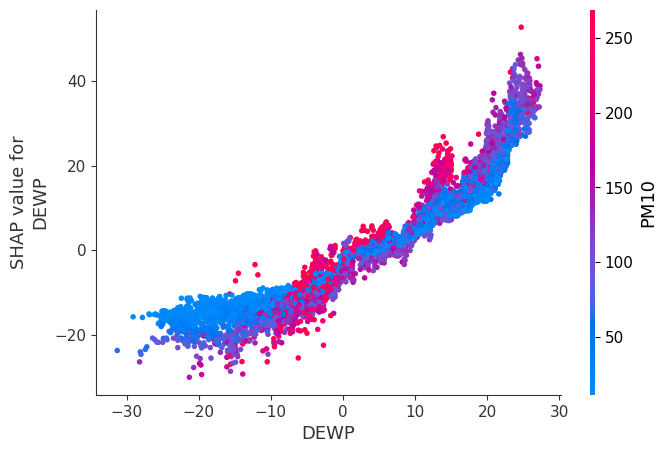

In [ ]:
shap.dependence_plot(
    "DEWP",
    shap_values,
    X_test
)

# Local SHAP Explanation

In addition to global feature importance, a local explanation is
generated for an individual test observation.

The local SHAP explanation shows which features increased or decreased
the model's prediction relative to the model's expected baseline.

In [ ]:
# Select one observation from the test set
sample_index = 0

sample = X_test.iloc[sample_index]

print("Selected observation:")
display(sample.to_frame().T)

print("\nActual PM2.5:", y_test.iloc[sample_index])
print("Predicted PM2.5:", pred_xgb[sample_index])

Selected observation:


,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,hour,month,day_of_week,year
28323,10.0,3.0,48.0,500.0,2.0,11.5,1001.9,8.5,0.0,0.4,3.0,5.0,1.0,2016.0



Actual PM2.5: 10.0
Predicted PM2.5: 16.714529


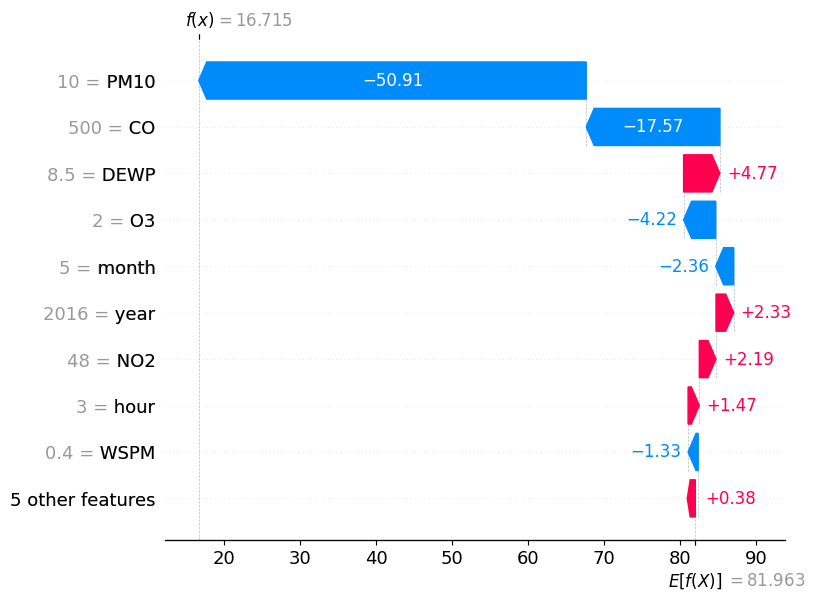

In [ ]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    )
)

# Prediction Error Findings

The prediction error distribution is concentrated around zero, indicating
that most XGBoost predictions are relatively close to the observed PM2.5
values.

The distribution also shows a positive right-skewed tail, indicating that
the model substantially underpredicts PM2.5 for a smaller number of
observations with relatively high pollution concentrations.

Negative errors represent observations where the model overpredicts the
actual PM2.5 concentration.

Overall, the error distribution indicates strong predictive performance
for the majority of observations, while extreme pollution episodes
remain more challenging for the model to estimate accurately.

In [ ]:
errors = y_test.values - pred_xgb

print("Mean Error:", errors.mean())
print("Mean Absolute Error:", np.abs(errors).mean())
print("Maximum Error:", errors.max())
print("Minimum Error:", errors.min())

Mean Error: 0.8060835793689174
Mean Absolute Error: 12.936695489569695
Maximum Error: 456.48353576660156
Minimum Error: -167.46571350097656


# Error Distribution

The distribution of prediction errors is visualized to assess the
overall behaviour of the XGBoost model.

A concentration of errors around zero indicates that predictions are
generally close to the observed values.

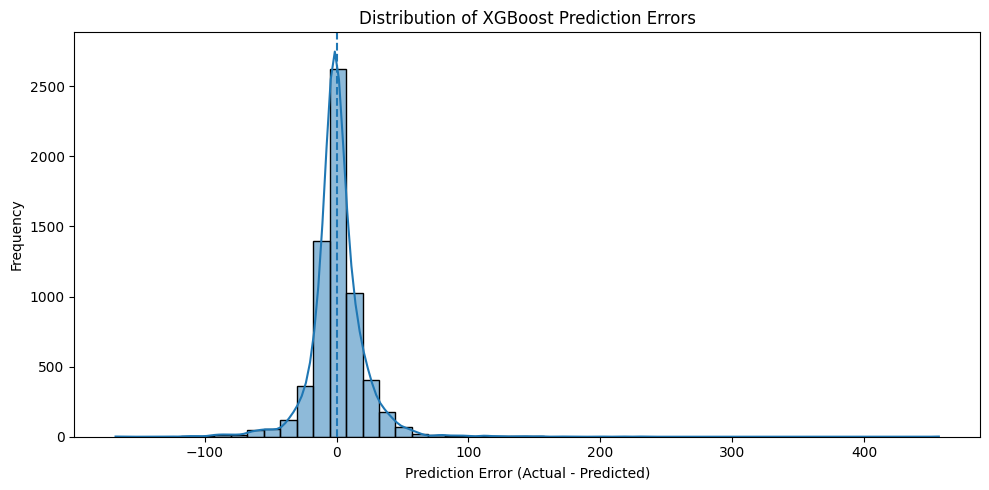

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    errors,
    bins=50,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of XGBoost Prediction Errors")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Research Questions and Findings

RQ1. Can machine learning models accurately predict PM2.5 concentration?

Yes. The evaluated machine learning models achieved strong predictive
performance. XGBoost achieved the highest R² of 0.9383, indicating that
the model explains approximately 93.83% of the variation in PM2.5
concentration in the test dataset.

RQ2. Which machine learning model provides the strongest predictive
performance?

Among the evaluated models, XGBoost provided the strongest overall
performance, achieving an MAE of 12.94, RMSE of 21.33 and R² of 0.9383.

RQ3. Which environmental variables have the greatest influence on
PM2.5 predictions?

The SHAP analysis identified PM10 as the dominant feature, followed by
CO and DEWP. This indicates that pollutant and meteorological variables
play an important role in the model's predictions.

RQ4. Can Explainable AI provide insight into the model's predictions?

Yes. SHAP provided both global and local explanations of the XGBoost
model, showing how individual environmental variables contribute to
predicted PM2.5 concentrations.

RQ5. Where does the model experience greater prediction difficulty?

The prediction error analysis indicates that most predictions are
concentrated near zero error, while a smaller number of high-pollution
observations produce substantially larger errors.

# Key Findings

The major findings of the AirSense-XAI study are:

1. XGBoost achieved the best overall predictive performance with an MAE
   of 12.94, RMSE of 21.33 and R² of 0.9383.

2. Random Forest also demonstrated strong performance with an R² of
   0.9354.

3. PM10 was the most influential predictor according to the SHAP
   analysis.

4. CO and DEWP were the second and third most influential features.

5. Environmental measurements had substantially greater influence on
   predictions than several temporal features.

6. SHAP successfully provided interpretable explanations of the
   XGBoost model.

7. Most prediction errors were concentrated around zero, although the
   model showed greater difficulty for some extreme pollution events.

# Limitations

Despite the strong predictive performance, this study has several
limitations.

First, the current analysis focuses on the Aotizhongxin monitoring
station. Therefore, the findings may not directly generalize to all
monitoring stations or other geographical regions.

Second, PM10 is the dominant predictor in the SHAP analysis. Since PM10
and PM2.5 are related particulate-matter measurements, the strong
importance of PM10 should be interpreted carefully.

Third, the current model predicts PM2.5 using measurements from the same
observation period. Therefore, the current experiment should be
considered PM2.5 concentration prediction rather than future forecasting.

Fourth, the model may have greater difficulty predicting extreme
pollution events, as indicated by the long tail in the prediction error
distribution.

Finally, additional validation across multiple monitoring stations and
different time periods would be required to establish broader
generalizability.

# Future Work

Several improvements can be explored in future research.

1. Multi-station modelling

The framework can be extended to all available Beijing monitoring
stations to evaluate geographical generalization.

2. Future PM2.5 forecasting

Lagged variables can be introduced to predict future PM2.5
concentrations, such as PM2.5 one hour, six hours or twenty-four hours
ahead.

3. Advanced time-series modelling

LSTM, GRU, Temporal Convolutional Networks and Transformer-based models
can be investigated for long-term temporal dependencies.

4. Advanced Explainable AI

Additional explanation techniques such as Partial Dependence,
Accumulated Local Effects and counterfactual explanations can be
investigated alongside SHAP.

5. Extreme pollution analysis

Specialized analysis can be performed on high-pollution episodes to
understand why prediction errors increase during extreme events.

6. Real-time deployment

The trained model could eventually be integrated into a real-time air
quality monitoring system that provides PM2.5 predictions together with
human-interpretable explanations.

7. Cross-region validation

The framework could be evaluated on air-quality datasets from other
cities or countries to investigate its transferability.

# Conclusion

This project developed AirSense-XAI, an explainable machine learning
framework for PM2.5 concentration prediction using air-quality and
meteorological observations.

Four regression models were evaluated: Linear Regression, Decision Tree,
Random Forest and XGBoost.

Among the evaluated models, XGBoost achieved the strongest performance,
with an MAE of 12.94, RMSE of 21.33 and R² of 0.9383 on the test data.

Explainable AI was incorporated using SHAP to investigate the factors
driving the model's predictions. PM10 was identified as the dominant
feature, followed by CO and DEWP.

The combination of strong predictive performance and model
interpretability demonstrates the potential of machine learning and
Explainable AI for air-quality analysis.

However, further research involving multi-station validation, future
forecasting and extreme pollution analysis is required before the
framework can be considered for broader real-world deployment.